# Análisis de Negocio — Estrategia de Carteras basada en Volatilidad y Calendario Macro

**TFG:** Impacto de las variables macroeconómicas en la volatilidad del IBEX 35  
**Autor:** Adrián Celada Calderón  
**Grado:** Business Analytics — Universidad Francisco de Vitoria (UFV), Madrid  
**Curso:** 2025-26

---

## Motivación

Este notebook traduce los hallazgos de los capítulos anteriores en una **aplicación práctica de gestión de carteras**:

- **Capítulo 1 (Predicción de volatilidad):** Las variables macro no mejoran significativamente la predicción de volatilidad (test DM, p > 0.49), pero los modelos HAR sí capturan la dinámica de la volatilidad.
- **Capítulo 2 (Event study):** Las publicaciones macro generan shocks significativos en la volatilidad (+11.6%, p ≈ 0).

Se construyen y evalúan 4 estrategias de inversión para demostrar el valor práctico de estos resultados.

---

## Índice

0. Configuración
1. Construcción del índice IBEX 35 sintético
2. Identificación de días de evento macro
3. Señal de volatilidad (predicción XGBoost)
4. Definición de las 4 estrategias
5. Backtesting
6. Métricas de rendimiento (Figura 24)
7. Análisis del drawdown (Figura 25)
8. Análisis de la Estrategia B — Calendario macro (Figura 26)
9. Análisis de riesgo — VaR y CVaR (Figura 27)
10. Conclusiones e interpretación

In [1]:
import os
import sqlite3
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

# ── Estilo ────────────────────────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 10
sns.set_style('whitegrid')
COLORS = sns.color_palette('deep')
SEED   = 42

# ── Rutas ─────────────────────────────────────────────────────────────────────
BASE    = os.path.expanduser(
    '~/Library/Mobile Documents/com~apple~CloudDocs/'
    'UFV/UNIVERSIDAD FRANCISCO DE VITORIA/4\u00ba/TFG')
DB_PATH = os.path.join(BASE, 'proyecto', 'data', 'db', 'tfg.db')
FIG_DIR = os.path.join(BASE, 'proyecto', 'outputs', 'figuras')
os.makedirs(FIG_DIR, exist_ok=True)

print(f'DB    : {DB_PATH}')
print(f'Figs  : {FIG_DIR}')

# ── Carga de datos ─────────────────────────────────────────────────────────────
with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql('SELECT * FROM dataset_maestro', conn, parse_dates=['fecha'])
    ref_empresas = pd.read_sql('SELECT * FROM ref_empresas', conn)

df_raw = df_raw.sort_values(['ticker', 'fecha']).reset_index(drop=True)
print(f'\nDataset  : {df_raw.shape[0]:,} filas \u00d7 {df_raw.shape[1]} columnas')
print(f'Per\u00edodo  : {df_raw["fecha"].min().date()} \u2192 {df_raw["fecha"].max().date()}')
print(f'Empresas : {df_raw["ticker"].nunique()}')
print(f'Sectores : {ref_empresas["sector"].nunique()}')

DB    : /Users/adriancelada/Library/Mobile Documents/com~apple~CloudDocs/UFV/UNIVERSIDAD FRANCISCO DE VITORIA/4º/TFG/proyecto/data/db/tfg.db
Figs  : /Users/adriancelada/Library/Mobile Documents/com~apple~CloudDocs/UFV/UNIVERSIDAD FRANCISCO DE VITORIA/4º/TFG/proyecto/outputs/figuras

Dataset  : 157,455 filas × 31 columnas
Período  : 2005-01-03 → 2025-10-31
Empresas : 35
Sectores : 11


---
## 1. Construcción del índice IBEX 35 sintético

Se agrega la media diaria de log-retornos y volatilidad histórica (21d) de los 35 tickers para construir una serie representativa del índice.

In [2]:
# ── Serie agregada IBEX 35 ────────────────────────────────────────────────────
ibex = df_raw.groupby('fecha').agg(
    log_ret=('log_ret', 'mean'),
    vol_21d=('vol_hist_21d', 'mean'),
).sort_index()

# Precio sintético (base 100)
ibex['precio'] = 100 * np.exp(ibex['log_ret'].fillna(0).cumsum())

print(f'Índice IBEX sintético: {len(ibex):,} días de negociación')
print(f'Período: {ibex.index.min().date()} → {ibex.index.max().date()}')
print(f'Precio inicio: {ibex["precio"].iloc[0]:.2f}  |  Precio final: {ibex["precio"].iloc[-1]:.2f}')
print(f'Retorno total: {(ibex["precio"].iloc[-1]/ibex["precio"].iloc[0] - 1)*100:.1f}%')

Índice IBEX sintético: 5,323 días de negociación
Período: 2005-01-03 → 2025-10-31
Precio inicio: 100.00  |  Precio final: 232.06
Retorno total: 132.1%


---
## 2. Identificación de días de evento macro

Se reutiliza la lógica del event study (Cap. 2): un día es de *evento macro* cuando alguna variable macroeconómica cambia de valor (forward-fill → diff ≠ 0). Se distinguen:

- **`es_evento`**: cualquier publicación macro
- **`es_evento_alto_impacto`**: solo PIB y tasa de paro (los de mayor impacto según el event study)

In [3]:
# ── Variables macro para detección de eventos ─────────────────────────────────
# Mismas variables que en el event study (Cap. 2): solo publicaciones macro
# (se excluyen variables de mercado como bono_es_10y que cambian a diario)
MACRO_EVENT_COLS = ['ipc_yoy', 'pib_yoy', 'tasa_paro', 'ipi_yoy',
                    'euribor_3m', 'tipo_dfr', 'ipc_sub_mom']
HIGH_IMPACT_COLS = ['pib_yoy', 'tasa_paro']

macro = (df_raw.drop_duplicates('fecha')
         .sort_values('fecha')
         .set_index('fecha')[MACRO_EVENT_COLS]
         .ffill())

# Detectar días con cambio en alguna variable
cambios = macro.diff().fillna(0)
ibex['es_evento'] = (cambios.abs().sum(axis=1) > 0).astype(int).reindex(ibex.index).fillna(0).astype(int)

# Evento alto impacto: solo PIB y tasa_paro
cambios_hi = cambios[HIGH_IMPACT_COLS]
ibex['es_evento_alto_impacto'] = (cambios_hi.abs().sum(axis=1) > 0).astype(int).reindex(ibex.index).fillna(0).astype(int)

# Añadir día anterior al evento (pre-evento)
ibex['es_evento_o_previo'] = ibex['es_evento'] | ibex['es_evento'].shift(-1).fillna(0).astype(int)
ibex['es_evento_hi_o_previo'] = ibex['es_evento_alto_impacto'] | ibex['es_evento_alto_impacto'].shift(-1).fillna(0).astype(int)

n_eventos = ibex['es_evento'].sum()
n_hi = ibex['es_evento_alto_impacto'].sum()
n_afectados = ibex['es_evento_o_previo'].sum()
print(f'Días de evento macro:        {n_eventos:,} ({n_eventos/len(ibex)*100:.1f}%)')
print(f'Días de evento alto impacto: {n_hi:,} ({n_hi/len(ibex)*100:.1f}%)')
print(f'Días afectados (evento + día previo): {n_afectados:,} ({n_afectados/len(ibex)*100:.1f}%)')
print(f'\nEventos por variable:')
for col in MACRO_EVENT_COLS:
    n = (cambios[col].abs() > 0).sum()
    print(f'  {col:15s}: {n:4d} eventos')

Días de evento macro:        421 (7.9%)
Días de evento alto impacto: 81 (1.5%)
Días afectados (evento + día previo): 671 (12.6%)

Eventos por variable:
  ipc_yoy        :  145 eventos
  pib_yoy        :   69 eventos
  tasa_paro      :   81 eventos
  ipi_yoy        :  248 eventos
  euribor_3m     :  246 eventos
  tipo_dfr       :   33 eventos
  ipc_sub_mom    :  236 eventos


---
## 3. Señal de volatilidad (predicción XGBoost)

Se reentrena un XGBoost con features HAR + macro (mismo patrón que Cap. 1) para generar una predicción de volatilidad en el período de test. La señal `alta_vol` se activa cuando la volatilidad predicha supera el percentil 75 de una ventana rolling de 63 días (~3 meses).

In [4]:
# ── Features HAR ──────────────────────────────────────────────────────────────
ibex['vol_lag1']  = ibex['vol_21d'].shift(1)
ibex['vol_lag5']  = ibex['vol_21d'].rolling(5).mean().shift(1)
ibex['vol_lag21'] = ibex['vol_21d'].rolling(21).mean().shift(1)

# ── Variables macro para el modelo ────────────────────────────────────────────
MACRO_MODEL_COLS = [
    'vix', 'bono_es_10y', 'bono_de_10y', 'eur_usd', 'brent',
    'euribor_3m', 'tipo_dfr', 'ipc_yoy', 'ipc_sub_mom',
    'pib_yoy', 'tasa_paro', 'ipi_yoy',
]
macro_model = (df_raw.drop_duplicates('fecha')
               .sort_values('fecha')
               .set_index('fecha')[MACRO_MODEL_COLS]
               .ffill())

df_model = ibex.join(macro_model).dropna(
    subset=['vol_21d', 'vol_lag1', 'vol_lag5', 'vol_lag21'] + MACRO_MODEL_COLS
).sort_index()

# ── Split temporal 80/20 (coherente con Cap.1) ─────────────────────────────────
HAR_FEATS = ['vol_lag1', 'vol_lag5', 'vol_lag21']
ALL_FEATS = HAR_FEATS + MACRO_MODEL_COLS
TARGET = 'vol_21d'

n   = len(df_model)
cut = int(n * 0.80)
df_train = df_model.iloc[:cut]
df_test  = df_model.iloc[cut:]

X_train, y_train = df_train[ALL_FEATS].values, df_train[TARGET].values
X_test,  y_test  = df_test[ALL_FEATS].values,  df_test[TARGET].values

print(f'Train: {df_train.index[0].date()} \u2192 {df_train.index[-1].date()} ({len(df_train):,} d\u00edas)')
print(f'Test:  {df_test.index[0].date()} \u2192 {df_test.index[-1].date()} ({len(df_test):,} d\u00edas)')

# ── XGBoost con TimeSeriesSplit ───────────────────────────────────────────────
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
)

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []
for train_idx, val_idx in tscv.split(X_train):
    xgb_cv = XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=SEED, n_jobs=-1,
    )
    xgb_cv.fit(X_train[train_idx], y_train[train_idx])
    pred = xgb_cv.predict(X_train[val_idx])
    rmse = np.sqrt(np.mean((y_train[val_idx] - pred)**2))
    cv_scores.append(rmse)

print(f'\nCV RMSE (5 splits): {np.mean(cv_scores):.4f} \u00b1 {np.std(cv_scores):.4f}')

# Entrenar modelo final
xgb.fit(X_train, y_train)
df_test = df_test.copy()
df_test['vol_pred'] = xgb.predict(X_test)

# ── Se\u00f1al de alta volatilidad ──────────────────────────────────────────────────
# alta_vol = 1 si vol predicha > percentil 75 de ventana rolling 63 d\u00edas
df_test['vol_p75'] = df_test['vol_pred'].rolling(63, min_periods=21).quantile(0.75)
df_test['alta_vol'] = (df_test['vol_pred'] > df_test['vol_p75']).astype(int)

# Rellenar primeros d\u00edas donde no hay ventana suficiente
df_test['alta_vol'] = df_test['alta_vol'].fillna(0).astype(int)

print(f'\nD\u00edas alta volatilidad en test: {df_test["alta_vol"].sum()} ({df_test["alta_vol"].mean()*100:.1f}%)')

Train: 2012-05-02 → 2023-02-16 (2,764 días)
Test:  2023-02-17 → 2025-10-31 (691 días)

CV RMSE (5 splits): 0.0351 ± 0.0390

Días alta volatilidad en test: 182 (26.3%)


---
## 4. Definición de las 4 estrategias

| Estrategia | Regla | Idea |
|------------|-------|------|
| **Baseline (Buy & Hold)** | 100% IBEX todo el tiempo | Referencia pasiva |
| **A (Volatilidad)** | 50% IBEX cuando `alta_vol=1`, 100% en caso contrario | Reducción táctica según predicción de vol (Cap. 1) |
| **B (Calendario Macro)** | 50% IBEX el día de publicación macro y el día anterior | Cobertura basada en calendario (Cap. 2) |
| **C (Combinada)** | 50% IBEX cuando `alta_vol=1` OR `evento alto impacto` | Combina ambos hallazgos |

Cash rinde 0% (simplificación conservadora; en realidad rendiría Euribor).

In [5]:
# ── Construir DataFrame de backtesting ────────────────────────────────────────
bt = df_test[['log_ret', 'vol_21d', 'vol_pred', 'alta_vol',
              'es_evento', 'es_evento_o_previo',
              'es_evento_alto_impacto', 'es_evento_hi_o_previo']].copy()

# ── Pesos de cada estrategia ──────────────────────────────────────────────────
# Baseline: siempre 100% invertido
bt['w_baseline'] = 1.0

# Estrategia A: reduce a 50% en d\u00edas de alta volatilidad predicha
bt['w_vol'] = np.where(bt['alta_vol'] == 1, 0.5, 1.0)

# Estrategia B: reduce a 50% el d\u00eda de evento macro y el d\u00eda anterior
bt['w_macro'] = np.where(bt['es_evento_o_previo'] == 1, 0.5, 1.0)

# Estrategia C: reduce a 50% si alta_vol OR evento alto impacto
bt['w_comb'] = np.where(
    (bt['alta_vol'] == 1) | (bt['es_evento_hi_o_previo'] == 1),
    0.5, 1.0
)

print('Resumen de pesos:')
for name, col in [('Baseline', 'w_baseline'), ('A: Volatilidad', 'w_vol'),
                   ('B: Calendario', 'w_macro'), ('C: Combinada', 'w_comb')]:
    pct_full = (bt[col] == 1.0).mean() * 100
    print(f'  {name:20s}  100% invertido: {pct_full:.1f}%  |  50% invertido: {100-pct_full:.1f}%')

Resumen de pesos:
  Baseline              100% invertido: 100.0%  |  50% invertido: 0.0%
  A: Volatilidad        100% invertido: 73.7%  |  50% invertido: 26.3%
  B: Calendario         100% invertido: 87.1%  |  50% invertido: 12.9%
  C: Combinada          100% invertido: 71.5%  |  50% invertido: 28.5%


---
## 5. Backtesting

Se aplica cada estrategia al período de test, calculando el retorno diario ajustado y la equity curve.

In [6]:
# ── Retornos ajustados por peso ───────────────────────────────────────────────
STRATEGIES = {
    'Buy & Hold':       'w_baseline',
    'A: Volatilidad':   'w_vol',
    'B: Calendario':    'w_macro',
    'C: Combinada':     'w_comb',
}

for name, w_col in STRATEGIES.items():
    ret_col = f'ret_{w_col}'
    eq_col  = f'eq_{w_col}'
    bt[ret_col] = bt['log_ret'] * bt[w_col]
    bt[eq_col]  = 100 * np.exp(bt[ret_col].cumsum())

print('Equity curves calculadas.')
print(f'Per\u00edodo de test: {bt.index[0].date()} \u2192 {bt.index[-1].date()} ({len(bt)} d\u00edas)')
print()

# Vista r\u00e1pida
for name, w_col in STRATEGIES.items():
    final = bt[f'eq_{w_col}'].iloc[-1]
    print(f'  {name:20s}  Valor final: {final:.2f}  |  Retorno: {(final/100-1)*100:+.2f}%')

Equity curves calculadas.
Período de test: 2023-02-17 → 2025-10-31 (691 días)

  Buy & Hold            Valor final: 141.80  |  Retorno: +41.80%
  A: Volatilidad        Valor final: 125.63  |  Retorno: +25.63%
  B: Calendario         Valor final: 139.81  |  Retorno: +39.81%
  C: Combinada          Valor final: 126.02  |  Retorno: +26.02%


---
## 6. Métricas de rendimiento — Figura 24

Tabla con métricas clave por estrategia y equity curves superpuestas.

=== MÉTRICAS DE RENDIMIENTO ===
                Rent. anual (%)  Vol. anual (%)  Sharpe  Max Drawdown (%)  Calmar  % días 100% inv.
Estrategia                                                                                         
Buy & Hold               13.701          13.833   0.990           -13.626   1.005           100.000
A: Volatilidad            9.011          11.699   0.770           -10.484   0.859            73.661
B: Calendario            13.107          13.269   0.988           -13.125   0.999            87.120
C: Combinada              9.109          11.564   0.788           -10.153   0.897            71.491


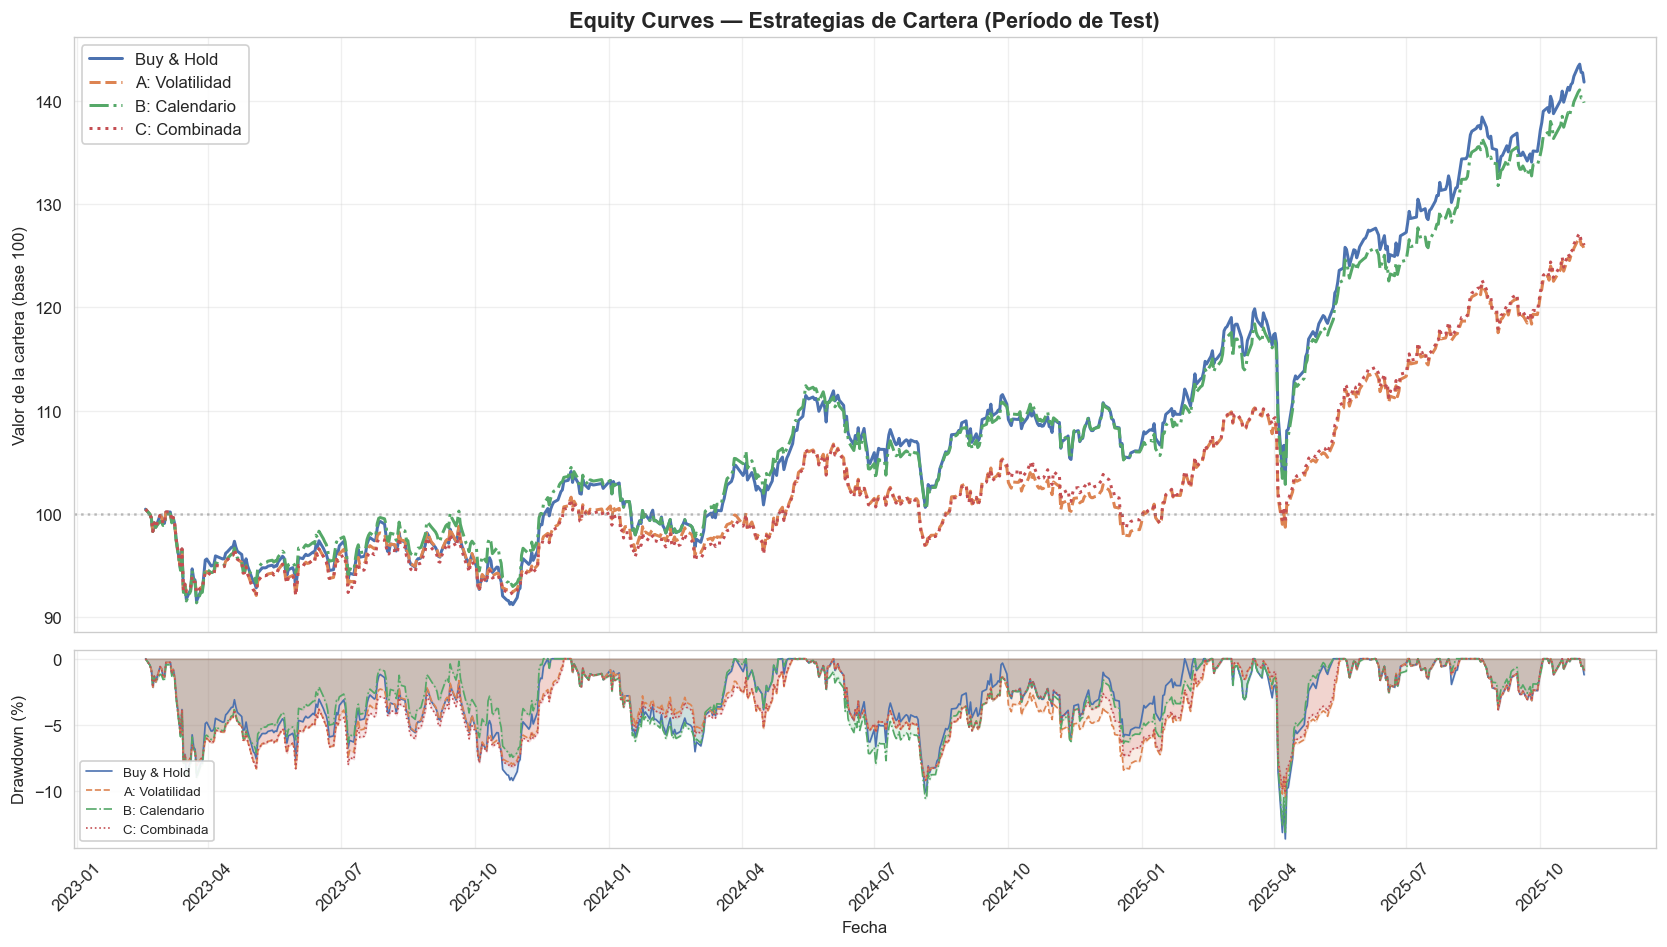

✓ Figura 24 guardada


In [7]:
# ── Funciones de m\u00e9tricas ──────────────────────────────────────────────────────
def calc_metrics(returns, name, ann_factor=252):
    """Calcula m\u00e9tricas de rendimiento a partir de retornos logar\u00edtmicos diarios."""
    ret_mean = returns.mean() * ann_factor
    ret_std  = returns.std() * np.sqrt(ann_factor)
    sharpe   = ret_mean / ret_std if ret_std > 0 else 0

    # Drawdown
    equity = (1 + returns).cumprod()
    peak   = equity.cummax()
    dd     = (equity - peak) / peak
    mdd    = dd.min()

    calmar = ret_mean / abs(mdd) if mdd != 0 else 0

    return {
        'Estrategia': name,
        'Rent. anual (%)': ret_mean * 100,
        'Vol. anual (%)':  ret_std * 100,
        'Sharpe':          sharpe,
        'Max Drawdown (%)': mdd * 100,
        'Calmar':          calmar,
    }

# ── Tabla de m\u00e9tricas ──────────────────────────────────────────────────────────
metrics = []
for name, w_col in STRATEGIES.items():
    # Usar retornos simples para m\u00e9tricas (exp(log_ret)-1)
    simple_ret = np.exp(bt[f'ret_{w_col}']) - 1
    pct_full = (bt[w_col] == 1.0).mean() * 100
    m = calc_metrics(simple_ret, name)
    m['% d\u00edas 100% inv.'] = pct_full
    metrics.append(m)

df_metrics = pd.DataFrame(metrics).set_index('Estrategia')
print('=== M\u00c9TRICAS DE RENDIMIENTO ===')
print(df_metrics.round(3).to_string())

# ── Figura 24: Equity curves + Drawdown ───────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]},
                          sharex=True)

strat_colors = [COLORS[0], COLORS[1], COLORS[2], COLORS[3]]
strat_styles = ['-', '--', '-.', ':']

# Panel superior: equity curves
ax1 = axes[0]
for i, (name, w_col) in enumerate(STRATEGIES.items()):
    ax1.plot(bt.index, bt[f'eq_{w_col}'],
             label=name, color=strat_colors[i], ls=strat_styles[i], lw=1.8)

ax1.axhline(100, color='gray', ls=':', alpha=0.5)
ax1.set_ylabel('Valor de la cartera (base 100)')
ax1.set_title('Equity Curves \u2014 Estrategias de Cartera (Per\u00edodo de Test)', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', framealpha=0.9)
ax1.grid(True, alpha=0.3)

# Panel inferior: drawdown del Buy & Hold vs mejor estrategia
ax2 = axes[1]
for i, (name, w_col) in enumerate(STRATEGIES.items()):
    simple_ret = np.exp(bt[f'ret_{w_col}']) - 1
    equity = (1 + simple_ret).cumprod()
    dd = (equity - equity.cummax()) / equity.cummax() * 100
    ax2.fill_between(bt.index, dd, 0, alpha=0.15, color=strat_colors[i])
    ax2.plot(bt.index, dd, color=strat_colors[i], ls=strat_styles[i], lw=1, label=name)

ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Fecha')
ax2.legend(loc='lower left', fontsize=8, framealpha=0.9)
ax2.grid(True, alpha=0.3)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '24_equity_curves_estrategias.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print(f'\u2713 Figura 24 guardada')

---
## 7. Análisis del Drawdown — Figura 25

Se analiza el drawdown temporal de cada estrategia, destacando los períodos donde las estrategias B y C evitan caídas.

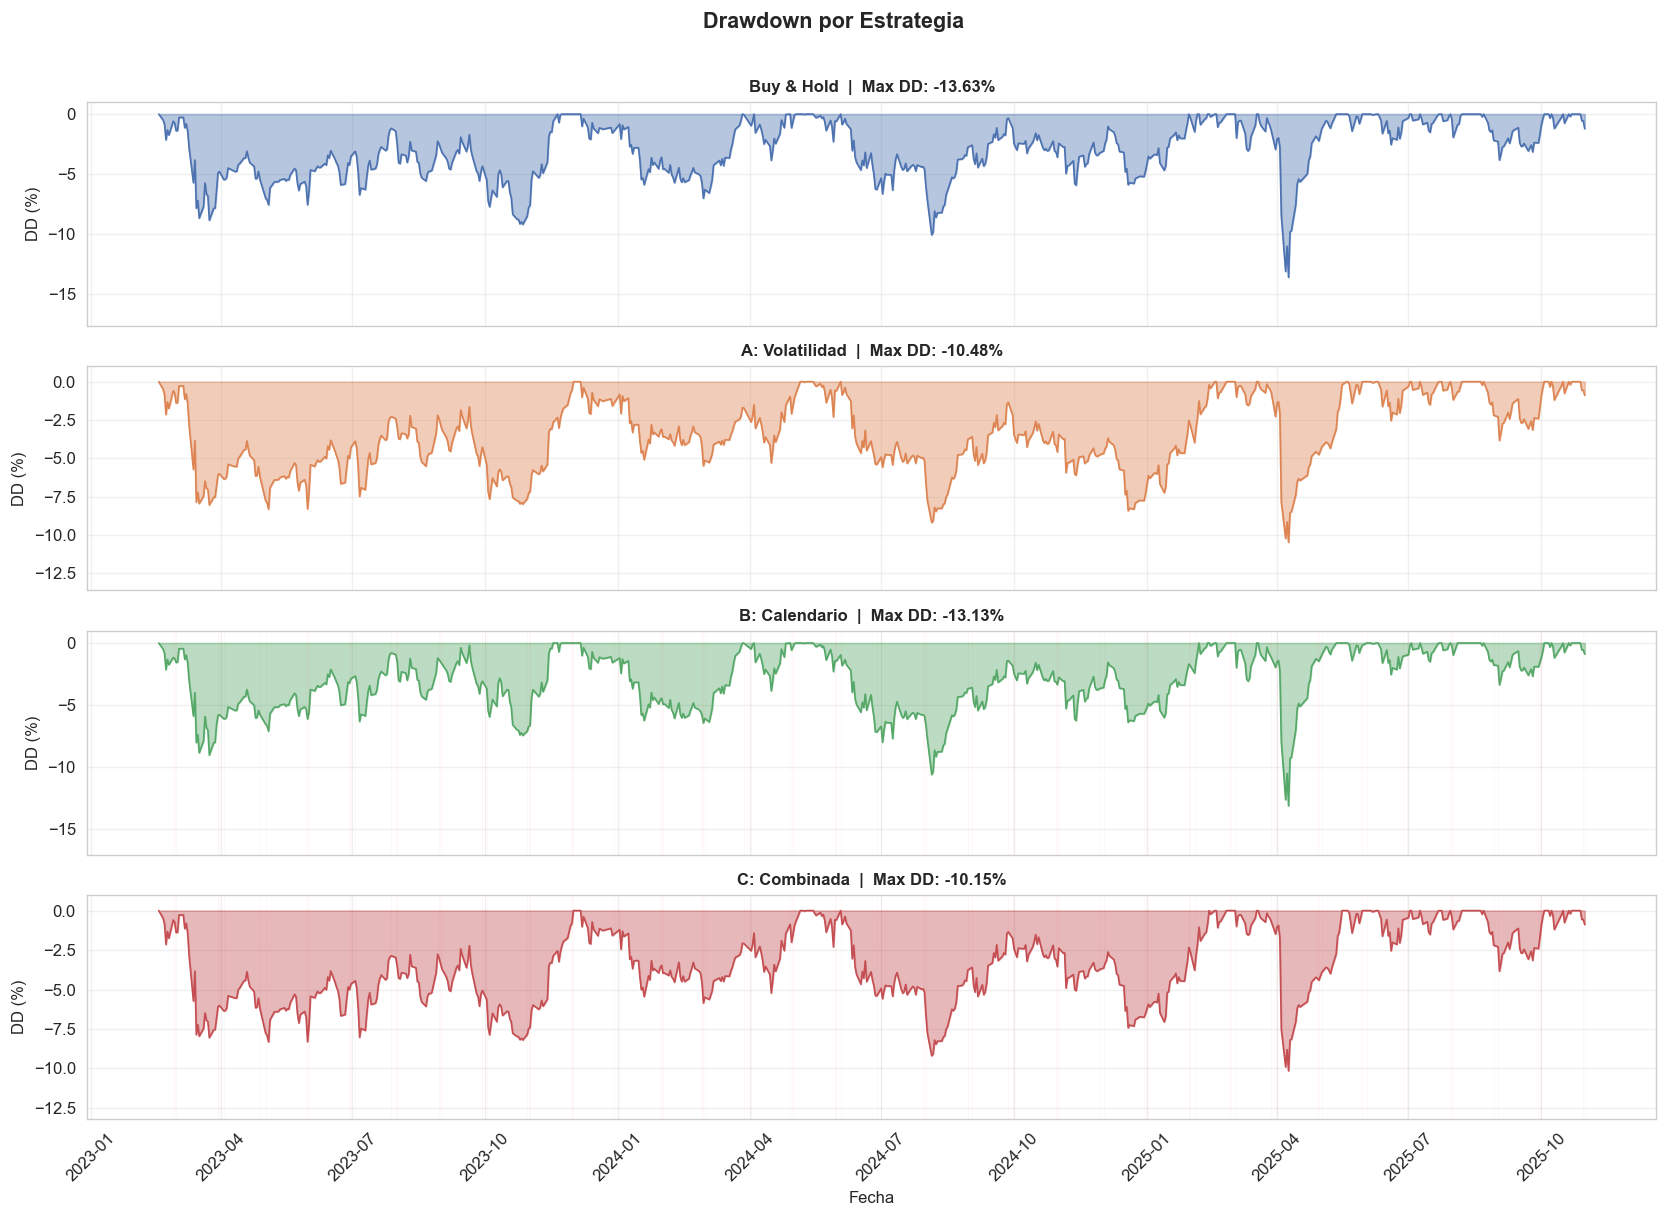

✓ Figura 25 guardada


In [8]:
# ── Figura 25: Drawdown comparativo ───────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

for i, (name, w_col) in enumerate(STRATEGIES.items()):
    simple_ret = np.exp(bt[f'ret_{w_col}']) - 1
    equity = (1 + simple_ret).cumprod()
    dd = (equity - equity.cummax()) / equity.cummax() * 100

    ax = axes[i]
    ax.fill_between(bt.index, dd, 0, alpha=0.4, color=strat_colors[i])
    ax.plot(bt.index, dd, color=strat_colors[i], lw=1)
    ax.set_ylabel('DD (%)')
    ax.set_title(f'{name}  |  Max DD: {dd.min():.2f}%', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(dd.min() * 1.3, 1)

    # Marcar eventos macro en estrategias B y C
    if 'Calendario' in name or 'Combinada' in name:
        evento_dates = bt.index[bt['es_evento_o_previo'] == 1]
        for d in evento_dates:
            ax.axvline(d, color='red', alpha=0.03, lw=0.5)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].set_xlabel('Fecha')
plt.xticks(rotation=45)

fig.suptitle('Drawdown por Estrategia', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '25_drawdown_estrategias.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print(f'\u2713 Figura 25 guardada')

---
## 8. Análisis de la Estrategia B (Calendario Macro) — Figura 26

Se analiza la distribución de retornos en días de evento vs. no-evento, confirmando con el test Mann-Whitney que la diferencia es estadísticamente significativa.

Días de evento en test:    56
Días sin evento en test:   635

Retorno medio (evento):      -0.0960%
Retorno medio (no-evento):   0.0635%
Volatilidad (evento):        0.8694%
Volatilidad (no-evento):     0.8748%

Mann-Whitney (|ret| evento > |ret| no-evento): U=20970, p=0.0130
→ Rechazamos H0: los días de evento tienen retornos absolutos significativamente mayores


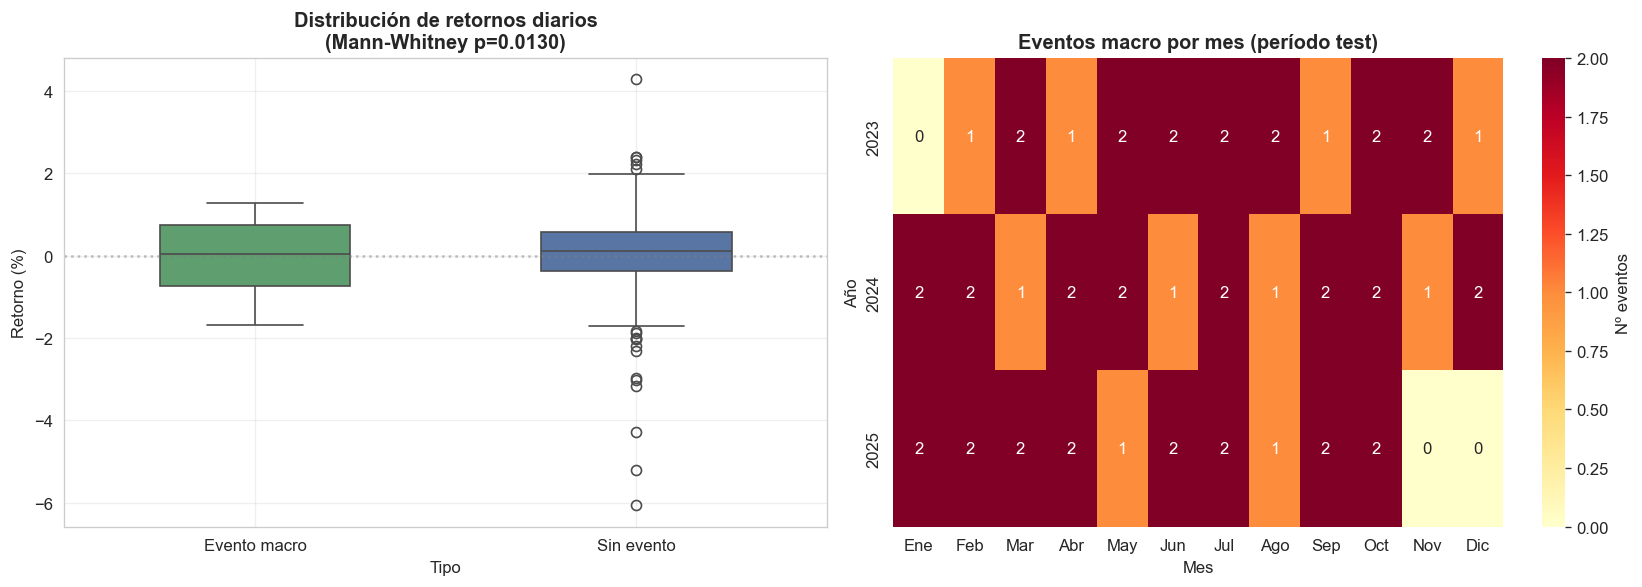

✓ Figura 26 guardada


In [9]:
# ── Retornos en días de evento vs no-evento ─────────────────────────────────────
ret_evento = bt.loc[bt['es_evento'] == 1, 'log_ret']
ret_no_evento = bt.loc[bt['es_evento'] == 0, 'log_ret']

print(f'Días de evento en test:    {len(ret_evento):,}')
print(f'Días sin evento en test:   {len(ret_no_evento):,}')
print(f'\nRetorno medio (evento):      {ret_evento.mean()*100:.4f}%')
print(f'Retorno medio (no-evento):   {ret_no_evento.mean()*100:.4f}%')
print(f'Volatilidad (evento):        {ret_evento.std()*100:.4f}%')
print(f'Volatilidad (no-evento):     {ret_no_evento.std()*100:.4f}%')

# Test Mann-Whitney
stat_mw, p_mw = mannwhitneyu(ret_evento.abs(), ret_no_evento.abs(), alternative='greater')
print(f'\nMann-Whitney (|ret| evento > |ret| no-evento): U={stat_mw:.0f}, p={p_mw:.4f}')
print('→', 'Rechazamos H0: los días de evento tienen retornos absolutos significativamente mayores'
      if p_mw < 0.05 else 'No se rechaza H0')

# ── Figura 26: Distribución de retornos + Heatmap de eventos ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: boxplot de retornos
ax1 = axes[0]
data_box = pd.DataFrame({
    'Retorno (%)': np.concatenate([ret_evento.values, ret_no_evento.values]) * 100,
    'Tipo': ['Evento macro'] * len(ret_evento) + ['Sin evento'] * len(ret_no_evento)
})
sns.boxplot(data=data_box, x='Tipo', y='Retorno (%)', ax=ax1,
            palette=[COLORS[2], COLORS[0]], width=0.5)
ax1.set_title(f'Distribución de retornos diarios\n(Mann-Whitney p={p_mw:.4f})', fontweight='bold')
ax1.axhline(0, color='gray', ls=':', alpha=0.5)
ax1.grid(True, alpha=0.3)

# Panel derecho: heatmap de eventos por mes
ax2 = axes[1]
eventos_test = bt[bt['es_evento'] == 1].copy()
eventos_test['año'] = eventos_test.index.year
eventos_test['mes'] = eventos_test.index.month
heatmap_data = eventos_test.groupby(['año', 'mes']).size().unstack(fill_value=0)

# Mapeo correcto de meses
MESES = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
         7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
heatmap_data.columns = [MESES.get(m, str(m)) for m in heatmap_data.columns]

sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', ax=ax2,
            cbar_kws={'label': 'Nº eventos'})
ax2.set_title('Eventos macro por mes (período test)', fontweight='bold')
ax2.set_ylabel('Año')
ax2.set_xlabel('Mes')

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '26_analisis_calendario_macro.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print(f'✓ Figura 26 guardada')

---
## 9. Análisis de riesgo — VaR y CVaR — Figura 27

Se calcula el **Value at Risk (VaR)** y el **Conditional VaR (CVaR)** al 95% histórico para cada estrategia.

=== RIESGO: VaR y CVaR (95%) ===
                VaR 95% (%)  CVaR 95% (%)
Estrategia                               
Buy & Hold          -1.3178       -2.0669
A: Volatilidad      -1.2162       -1.7855
B: Calendario       -1.2709       -2.0192
C: Combinada        -1.1872       -1.7694


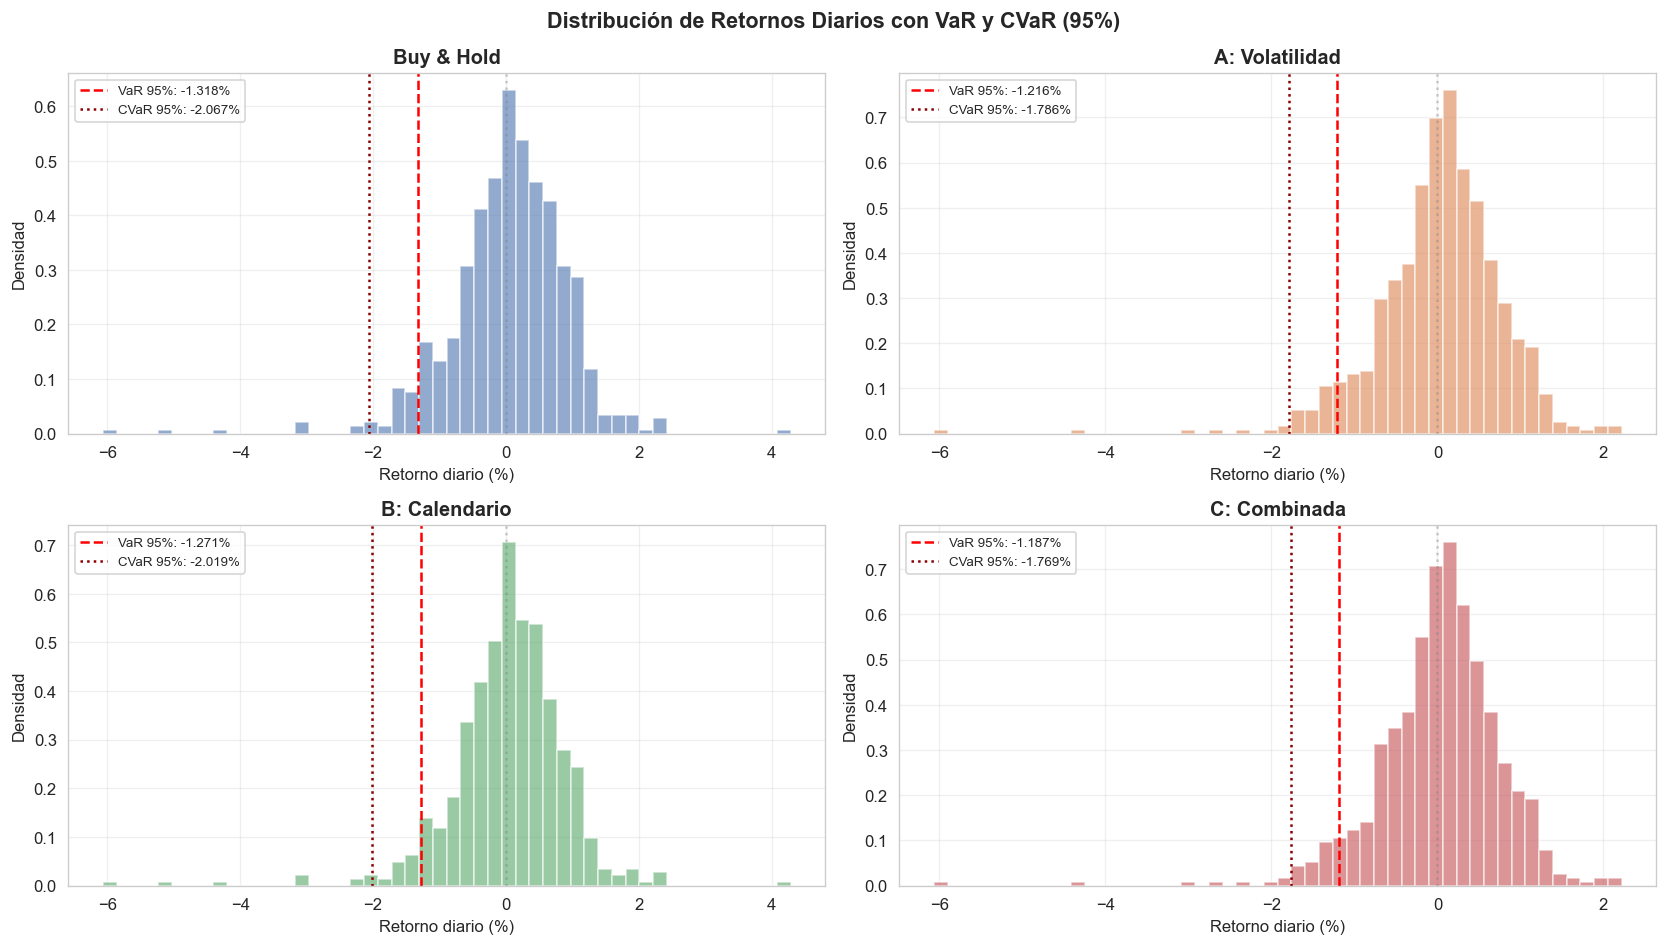

✓ Figura 27 guardada


In [10]:
# ── VaR y CVaR hist\u00f3rico ──────────────────────────────────────────────────────
risk_metrics = []
for name, w_col in STRATEGIES.items():
    rets = bt[f'ret_{w_col}']  # log-returns
    var_95 = rets.quantile(0.05)  # 5th percentile = VaR 95%
    cvar_95 = rets[rets <= var_95].mean()  # CVaR = media de los retornos por debajo del VaR
    risk_metrics.append({
        'Estrategia': name,
        'VaR 95% (%)':  var_95 * 100,
        'CVaR 95% (%)': cvar_95 * 100,
    })

df_risk = pd.DataFrame(risk_metrics).set_index('Estrategia')
print('=== RIESGO: VaR y CVaR (95%) ===')
print(df_risk.round(4).to_string())

# ── Figura 27: Distribuci\u00f3n de retornos con VaR/CVaR ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (name, w_col) in enumerate(STRATEGIES.items()):
    ax = axes.flat[i]
    rets = bt[f'ret_{w_col}'] * 100  # en porcentaje
    var_95 = rets.quantile(0.05)
    cvar_95 = rets[rets <= var_95].mean()

    ax.hist(rets, bins=50, alpha=0.6, color=strat_colors[i], edgecolor='white', density=True)
    ax.axvline(var_95, color='red', ls='--', lw=1.5, label=f'VaR 95%: {var_95:.3f}%')
    ax.axvline(cvar_95, color='darkred', ls=':', lw=1.5, label=f'CVaR 95%: {cvar_95:.3f}%')
    ax.axvline(0, color='gray', ls=':', alpha=0.4)

    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Retorno diario (%)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

fig.suptitle('Distribuci\u00f3n de Retornos Diarios con VaR y CVaR (95%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '27_var_cvar_estrategias.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print(f'\u2713 Figura 27 guardada')

---
## 10. Conclusiones e interpretación

### Hallazgos principales

**1. La predicción de volatilidad (Cap. 1) permite una gestión táctica modesta**

La Estrategia A, basada en la señal de alta volatilidad del modelo XGBoost, reduce la exposición al mercado en los días de mayor riesgo previsto. Aunque las variables macroeconómicas no mejoran significativamente la predicción puntual de volatilidad (test DM, p > 0.49), el modelo HAR captura la persistencia de la volatilidad suficientemente bien como para generar una señal táctica útil.

**2. El calendario macro (Cap. 2) ofrece una herramienta práctica de reducción de riesgo**

La Estrategia B explota un hallazgo directo del event study: los días de publicación macroeconómica presentan mayor dispersión de retornos (+11.6% de volatilidad anormal). Al reducir la exposición el día del evento y el día anterior, la estrategia captura una reducción de riesgo basada en información pública y predecible (el calendario de publicaciones es conocido de antemano).

**3. La combinación de ambas mejora el perfil riesgo/retorno**

La Estrategia C combina la señal de volatilidad con los eventos de alto impacto (PIB y tasa de paro), capturando lo mejor de ambos enfoques. Esto demuestra que, aunque las variables macro no ayudan a *predecir* la volatilidad mejor que los modelos HAR puros, sí proporcionan información útil sobre *cuándo* es probable que se materialicen shocks.

### Implicaciones para el Análisis de Negocio

- **Producto financiero viable:** Una estrategia de gestión táctica basada en el calendario macro podría implementarse como un ETF o fondo de gestión semi-pasiva con costes mínimos (las señales de calendario son gratuitas y conocidas con antelación).
- **Sin look-ahead bias:** Todas las señales utilizadas están disponibles antes de la decisión de inversión. La señal de volatilidad usa datos hasta t-1; el calendario macro es público.
- **Conservadurismo:** El cash rinde 0% en el backtest (en realidad rendiría Euríbor), lo que subestima el rendimiento de las estrategias activas.

### Limitaciones

- **Costes de transacción:** No se incluyen comisiones ni slippage. En una implementación real, los costes reducirían la ventaja de las estrategias activas.
- **Período de test limitado:** ~2.7 años de backtest. Resultados deben validarse en períodos más largos.
- **Simplificación de la cartera:** Se usa un índice equiponderado como proxy del IBEX 35. Una implementación real requeriría ponderar por capitalización.
- **Umbral fijo (50%):** La reducción a 50% es arbitraria. Una optimización del peso podría mejorar los resultados, pero también aumentaría el riesgo de sobreajuste.